# **Aprendizaje Basado en Problemas (ABP)**

Codigo principal organizado por:

* Sherman Abarca
* Valeria Agila
* Domenica Narvaez
* Gabriel Suarez
* Diyer Torres
* José Valencia

1. **Configuración:** Preparar el entorno en Google Colab o Jupyter Notebook importando las librerías numpy, scipy.stats, matplotlib y seaborn.



In [1]:
# ============================================================
# PRÁCTICA: Variables Aleatorias - PMF, PDF y CDF
# Probabilidad y Estadística — UNL
# ============================================================

# --- Librerías principales ---
import numpy as np                    # Operaciones numéricas y arrays
import matplotlib.pyplot as plt        # Visualizaciones base
import seaborn as sns                   # Visualizaciones estadísticas
from scipy import stats                 # Distribuciones y pruebas estadísticas
import itertools                         # Generación de espacios muestrales

# --- Configuración visual ---
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"]    = 100

# --- Semilla para reproducibilidad ---
np.random.seed(42)

print("✓ Librerías cargadas correctamente")
print(f"  numpy      {np.__version__}")
print(f"  matplotlib {plt.matplotlib.__version__}")
print(f"  seaborn    {sns.__version__}")

✓ Librerías cargadas correctamente
  numpy      2.0.2
  matplotlib 3.10.0
  seaborn    0.13.2


2. **Caso Discreto (Lanzamiento de Dado):** Definir la PMF para un dado justo, generar su CDF y calcular probabilidades específicas como $P(X \leq 3)$ y $P(2 \leq X \leq 5)$.

In [2]:
# ============================================================
# TAREA 2: Caso Discreto — Dado justo de 6 caras
# ============================================================

# Espacio muestral: todos los resultados posibles
caras = np.arange(1, 7)            # [1, 2, 3, 4, 5, 6]

# PMF: para un dado justo, cada cara tiene prob = 1/6
pmf = np.ones(6) / 6

# CDF: suma acumulada de la PMF
cdf = np.cumsum(pmf)

# Mostrar tabla de valores
print("Cara | PMF        | CDF")
print("-" * 30)
for x, p, c in zip(caras, pmf, cdf):
    print(f"  {x}  |  {p:.4f}    |  {c:.4f}")

Cara | PMF        | CDF
------------------------------
  1  |  0.1667    |  0.1667
  2  |  0.1667    |  0.3333
  3  |  0.1667    |  0.5000
  4  |  0.1667    |  0.6667
  5  |  0.1667    |  0.8333
  6  |  0.1667    |  1.0000


In [3]:
# ============================================================
# Probabilidades específicas solicitadas en la práctica
# ============================================================

# P(X <= 3): suma de PMF para caras 1, 2, 3
p_leq3 = np.sum(pmf[caras <= 3])
print(f"P(X ≤ 3)       = {p_leq3:.4f}  →  {p_leq3*100:.1f}%")

# P(2 <= X <= 5): suma de PMF para caras 2, 3, 4, 5
mascara = (caras >= 2) & (caras <= 5)
p_2a5   = np.sum(pmf[mascara])
print(f"P(2 ≤ X ≤ 5)   = {p_2a5:.4f}  →  {p_2a5*100:.1f}%")

# Verificación: suma total de la PMF debe ser 1
print(f"\nVerificación suma PMF = {np.sum(pmf):.1f}  ✓")

P(X ≤ 3)       = 0.5000  →  50.0%
P(2 ≤ X ≤ 5)   = 0.6667  →  66.7%

Verificación suma PMF = 1.0  ✓


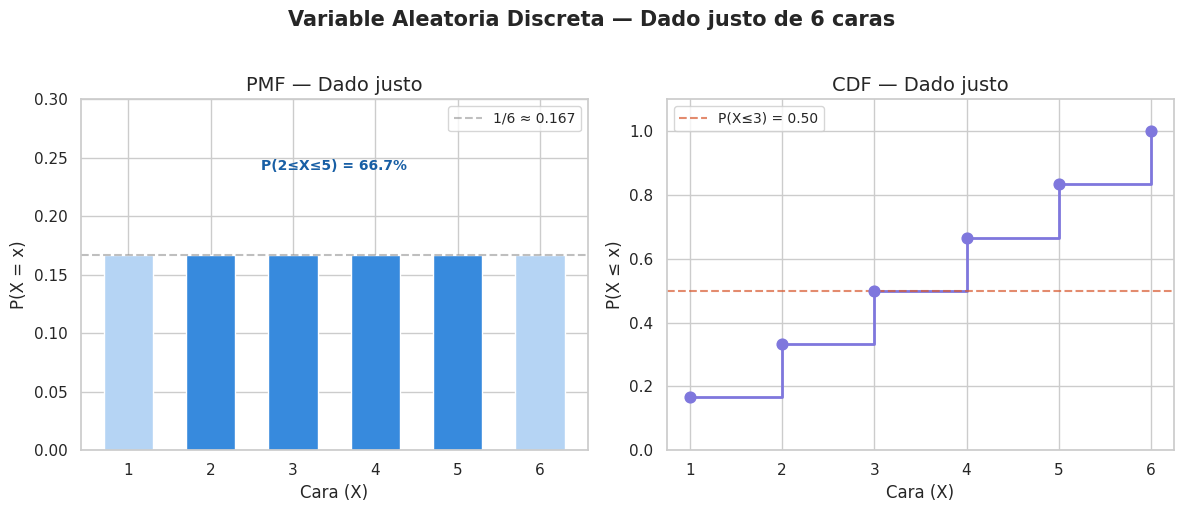

In [4]:
# ============================================================
# Gráfica lado a lado: PMF  |  CDF
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- PMF ---
colores = ['#378ADD' if 2 <= x <= 5 else '#B5D4F4' for x in caras]
ax1.bar(caras, pmf, color=colores, edgecolor='white', width=0.6)
ax1.set_title("PMF — Dado justo", fontsize=14)
ax1.set_xlabel("Cara (X)")
ax1.set_ylabel("P(X = x)")
ax1.set_xticks(caras)
ax1.set_ylim(0, 0.30)
ax1.axhline(1/6, color='gray', linestyle='--', alpha=0.5, label='1/6 ≈ 0.167')
ax1.legend(fontsize=10)

# Anotar P(2<=X<=5) en azul oscuro
ax1.text(3.5, 0.24, 'P(2≤X≤5) = 66.7%',
         ha='center', color='#185FA5', fontsize=10, fontweight='bold')

# --- CDF ---
ax2.step(caras, cdf, where='post', color='#7F77DD', linewidth=2)
ax2.scatter(caras, cdf, color='#7F77DD', zorder=5, s=60)
ax2.axhline(0.5, color='#D85A30', linestyle='--', alpha=0.7, label='P(X≤3) = 0.50')
ax2.set_title("CDF — Dado justo", fontsize=14)
ax2.set_xlabel("Cara (X)")
ax2.set_ylabel("P(X ≤ x)")
ax2.set_xticks(caras)
ax2.set_ylim(0, 1.1)
ax2.legend(fontsize=10)

plt.suptitle("Variable Aleatoria Discreta — Dado justo de 6 caras",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

3. **Caso Continuo (Servidor Web):** Modelar el tiempo de respuesta ($\mu = 200$, $\sigma = 30$) mediante una distribución normal. Calcular el percentil 95 de la operación.

In [5]:
# ============================================================
# TAREA 3: Caso Continuo — Tiempo de respuesta de servidor web
# Distribución Normal con μ=200ms, σ=30ms
# ============================================================

# Parámetros de la distribución
mu    = 200   # media en milisegundos
sigma = 30    # desviación estándar en milisegundos

# Crear objeto de distribución normal con scipy
distribucion = stats.norm(loc=mu, scale=sigma)

# Eje X: rango realista de tiempos (μ ± 4σ)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)

# Evaluar PDF y CDF en cada punto
pdf_vals = distribucion.pdf(x)
cdf_vals = distribucion.cdf(x)

print(f"Distribución : Normal(μ={mu}, σ={sigma})")
print(f"Rango X      : [{x[0]:.1f} ms, {x[-1]:.1f} ms]")
print(f"Pico PDF     : {max(pdf_vals):.6f}  en x = {mu} ms")

Distribución : Normal(μ=200, σ=30)
Rango X      : [80.0 ms, 320.0 ms]
Pico PDF     : 0.013298  en x = 200 ms


In [6]:
# ============================================================
# Cálculo de probabilidades clave y percentil 95
# ============================================================

# Percentil 95: el 95% de las peticiones responden antes de este tiempo
p95 = distribucion.ppf(0.95)
print(f"Percentil 95         : {p95:.2f} ms")
print(f"  → El 95% de las peticiones responden en menos de {p95:.1f} ms\n")

# P(X < 200): probabilidad de responder antes de la media
p_lt200 = distribucion.cdf(200)
print(f"P(X < 200 ms)        : {p_lt200:.4f}  →  {p_lt200*100:.1f}%")

# P(170 < X < 230): tiempo dentro de ±1 desviación estándar
p_rango = distribucion.cdf(230) - distribucion.cdf(170)
print(f"P(170 < X < 230 ms)  : {p_rango:.4f}  →  {p_rango*100:.1f}%")

# P(X > 260): peticiones lentas (más de μ+2σ)
p_lento = 1 - distribucion.cdf(260)
print(f"P(X > 260 ms)        : {p_lento:.4f}  →  {p_lento*100:.2f}%")

Percentil 95         : 249.35 ms
  → El 95% de las peticiones responden en menos de 249.3 ms

P(X < 200 ms)        : 0.5000  →  50.0%
P(170 < X < 230 ms)  : 0.6827  →  68.3%
P(X > 260 ms)        : 0.0228  →  2.28%


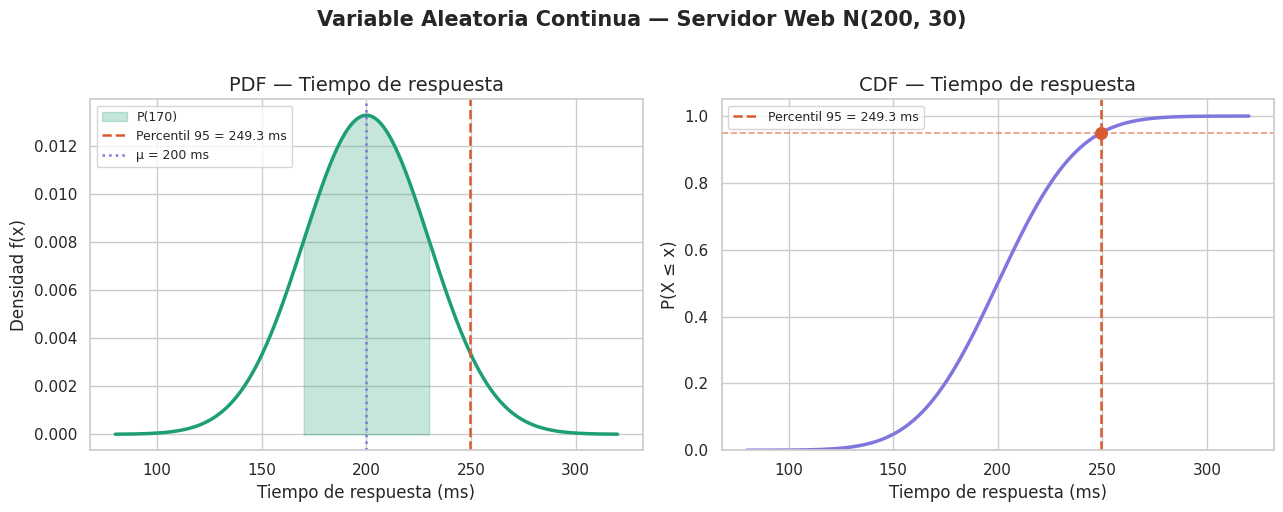

In [7]:
# ============================================================
# Gráfica lado a lado: PDF  |  CDF
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- PDF ---
ax1.plot(x, pdf_vals, color='#1D9E75', linewidth=2.5)

# Área sombreada: zona ±1σ (68.3%)
x_fill = np.linspace(170, 230, 300)
ax1.fill_between(x_fill, distribucion.pdf(x_fill), alpha=0.25, color='#1D9E75', label='P(170)')

# Línea del percentil 95
ax1.axvline(p95, color='#D85A30', linestyle='--', linewidth=1.8,
            label=f'Percentil 95 = {p95:.1f} ms')

# Línea de la media
ax1.axvline(mu, color='#7F77DD', linestyle=':', linewidth=1.8,
            label=f'μ = {mu} ms')

ax1.set_title("PDF — Tiempo de respuesta", fontsize=14)
ax1.set_xlabel("Tiempo de respuesta (ms)")
ax1.set_ylabel("Densidad f(x)")
ax1.legend(fontsize=9)

# --- CDF ---
ax2.plot(x, cdf_vals, color='#7F77DD', linewidth=2.5)

# Marcar el percentil 95 en la CDF
ax2.axvline(p95, color='#D85A30', linestyle='--', linewidth=1.8,
            label=f'Percentil 95 = {p95:.1f} ms')
ax2.axhline(0.95, color='#D85A30', linestyle='--', linewidth=1.2, alpha=0.6)
ax2.scatter([p95], [0.95], color='#D85A30', zorder=5, s=70)

ax2.set_title("CDF — Tiempo de respuesta", fontsize=14)
ax2.set_xlabel("Tiempo de respuesta (ms)")
ax2.set_ylabel("P(X ≤ x)")
ax2.set_ylim(0, 1.05)
ax2.legend(fontsize=9)

plt.suptitle("Variable Aleatoria Continua — Servidor Web N(200, 30)",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

4. **Análisis Comparativo:** Crear una visualización dual que permita contrastar el concepto de "probabilidad en puntos específicos" (discreta) vs. "área bajo la curva" (continua).

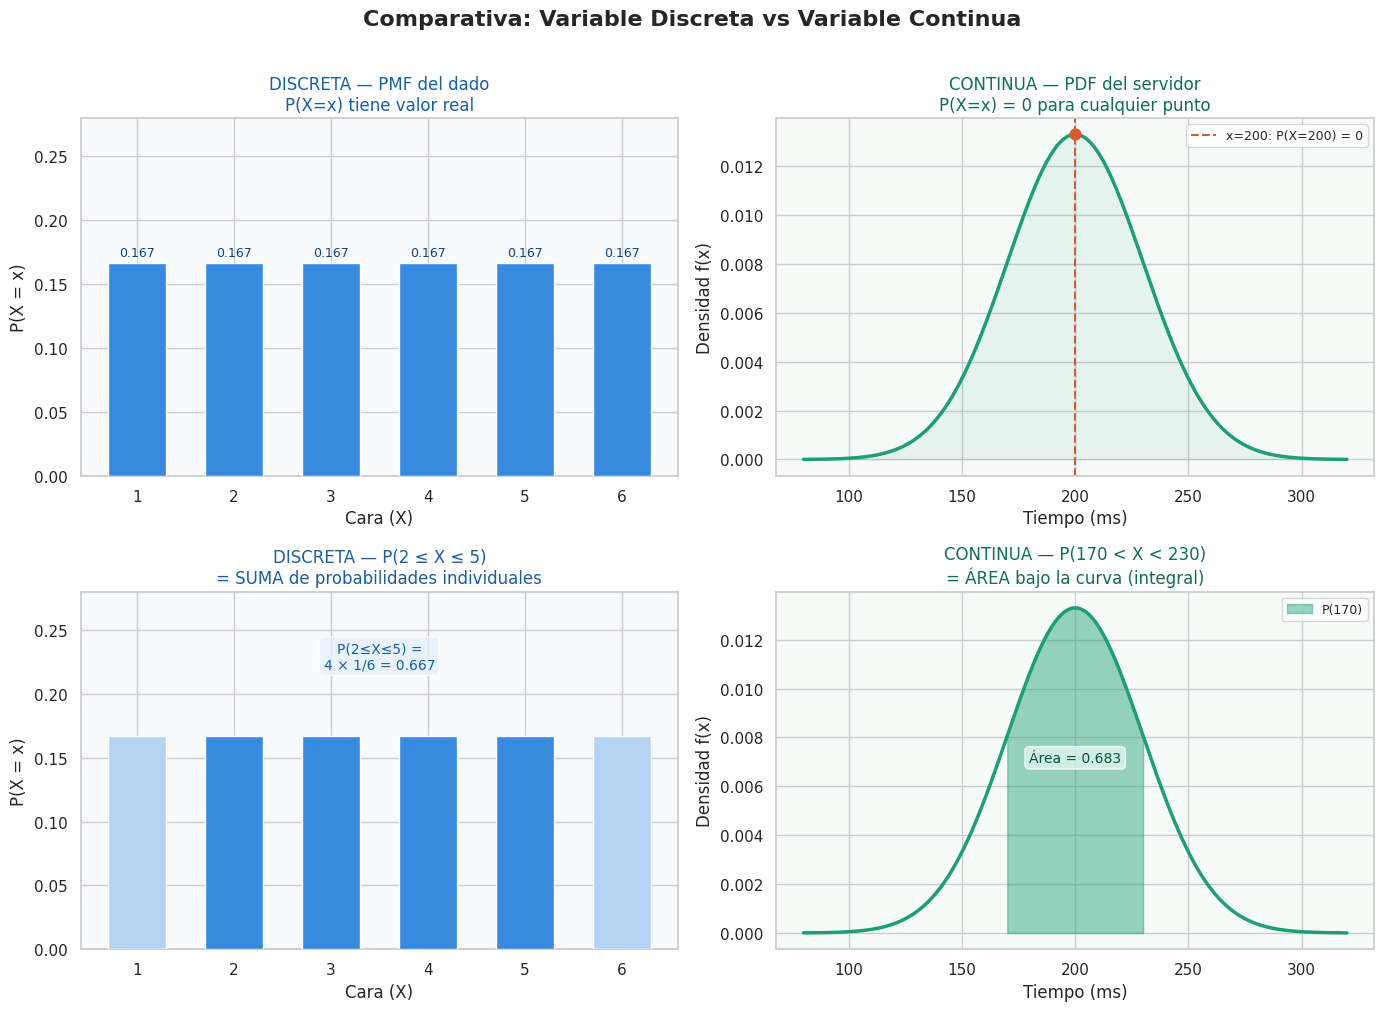

In [8]:
# ============================================================
# TAREA 4: Análisis Comparativo
# Discreta (probabilidad en puntos) vs Continua (área bajo curva)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Comparativa: Variable Discreta vs Variable Continua",
             fontsize=16, fontweight='bold', y=1.01)

# ── Fila superior: PMF discreta vs PDF continua ──────────────

# [0,0] PMF del dado — probabilidad en puntos exactos
ax = axes[0, 0]
ax.bar(caras, pmf, color='#378ADD', edgecolor='white', width=0.6, zorder=3)
for xi, pi in zip(caras, pmf):
    ax.text(xi, pi + 0.005, f'{pi:.3f}', ha='center', fontsize=9,
            color='#0C447C')
ax.set_title("DISCRETA — PMF del dado\nP(X=x) tiene valor real",
             fontsize=12, color='#185FA5')
ax.set_xlabel("Cara (X)"); ax.set_ylabel("P(X = x)")
ax.set_xticks(caras); ax.set_ylim(0, 0.28)
ax.set_facecolor('#F8FAFD')

# [0,1] PDF del servidor — densidad, NO probabilidad directa
ax = axes[0, 1]
ax.plot(x, pdf_vals, color='#1D9E75', linewidth=2.5)
ax.fill_between(x, pdf_vals, alpha=0.08, color='#1D9E75')
# Marcar un punto específico para mostrar que P(X=x)=0
x_punto = 200
ax.axvline(x_punto, color='#D85A30', linestyle='--', linewidth=1.5,
           label=f'x={x_punto}: P(X={x_punto}) = 0')
ax.scatter([x_punto], [distribucion.pdf(x_punto)],
           color='#D85A30', zorder=5, s=60)
ax.set_title("CONTINUA — PDF del servidor\nP(X=x) = 0 para cualquier punto",
             fontsize=12, color='#0F6E56')
ax.set_xlabel("Tiempo (ms)"); ax.set_ylabel("Densidad f(x)")
ax.legend(fontsize=9); ax.set_facecolor('#F6FBF8')

# ── Fila inferior: probabilidad en rango ─────────────────────

# [1,0] Discreta: P(2 <= X <= 5) — suma de barras
ax = axes[1, 0]
colores_rango = ['#378ADD' if 2 <= xi <= 5 else '#B5D4F4' for xi in caras]
ax.bar(caras, pmf, color=colores_rango, edgecolor='white', width=0.6, zorder=3)
ax.set_title("DISCRETA — P(2 ≤ X ≤ 5)\n= SUMA de probabilidades individuales",
             fontsize=12, color='#185FA5')
ax.set_xlabel("Cara (X)"); ax.set_ylabel("P(X = x)")
ax.set_xticks(caras); ax.set_ylim(0, 0.28)
ax.text(3.5, 0.22, 'P(2≤X≤5) =\n4 × 1/6 = 0.667',
        ha='center', fontsize=10, color='#185FA5',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E6F1FB', alpha=0.8))
ax.set_facecolor('#F8FAFD')

# [1,1] Continua: P(170 < X < 230) — área bajo la curva
ax = axes[1, 1]
ax.plot(x, pdf_vals, color='#1D9E75', linewidth=2.5)
x_area = np.linspace(170, 230, 300)
ax.fill_between(x_area, distribucion.pdf(x_area),
                alpha=0.45, color='#1D9E75',
                label='P(170)')
ax.set_title("CONTINUA — P(170 < X < 230)\n= ÁREA bajo la curva (integral)",
             fontsize=12, color='#0F6E56')
ax.set_xlabel("Tiempo (ms)"); ax.set_ylabel("Densidad f(x)")
ax.legend(fontsize=9)
ax.text(200, 0.007, 'Área = 0.683',
        ha='center', fontsize=10, color='#085041',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#E1F5EE', alpha=0.8))
ax.set_facecolor('#F6FBF8')

plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# Resumen comparativo en texto
# ============================================================

resumen = """
╔══════════════════════════╦══════════════════════╦══════════════════════╗
║ Característica           ║ DISCRETA (Dado)      ║ CONTINUA (Servidor)  ║
╠══════════════════════════╬══════════════════════╬══════════════════════╣
║ Valores posibles         ║ {1, 2, 3, 4, 5, 6}   ║ Cualquier real > 0   ║
║ Función de prob.         ║ PMF  P(X=x) > 0      ║ PDF  P(X=x) = 0      ║
║ Prob. en un punto        ║ Sí, tiene valor real ║ Siempre es cero      ║
║ Prob. en un rango        ║ Suma de P(X=xi)      ║ Integral (área)      ║
║ Herramienta scipy        ║ No aplica (manual)   ║ stats.norm(200, 30)  ║
║ Suma/integral total      ║ Σ P(X=x) = 1         ║ ∫f(x)dx = 1          ║
╚══════════════════════════╩══════════════════════╩══════════════════════╝
"""
print(resumen)


╔══════════════════════════╦══════════════════════╦══════════════════════╗
║ Característica           ║ DISCRETA (Dado)      ║ CONTINUA (Servidor)  ║
╠══════════════════════════╬══════════════════════╬══════════════════════╣
║ Valores posibles         ║ {1, 2, 3, 4, 5, 6}   ║ Cualquier real > 0   ║
║ Función de prob.         ║ PMF  P(X=x) > 0      ║ PDF  P(X=x) = 0      ║
║ Prob. en un punto        ║ Sí, tiene valor real ║ Siempre es cero      ║
║ Prob. en un rango        ║ Suma de P(X=xi)      ║ Integral (área)      ║
║ Herramienta scipy        ║ No aplica (manual)   ║ stats.norm(200, 30)  ║
║ Suma/integral total      ║ Σ P(X=x) = 1         ║ ∫f(x)dx = 1          ║
╚══════════════════════════╩══════════════════════╩══════════════════════╝



5. **Identificación en el Campus:** En grupos de 2 a 3 personas, registrar 5 variables aleatorias observadas en áreas de la UNL (Biblioteca, Cafetería, etc.), clasificándolas por tipo y distribución esperada.



In [10]:
# ============================================================
# TAREA: Variables aleatorias observadas en el entorno (UNL)
# ============================================================

import pandas as pd

variables_unl = [
    {
        'nombre'              : 'Número de libros prestados por hora',
        'ubicacion'           : 'Biblioteca',
        'tipo'                : 'Discreta',
        'valores_posibles'    : '0, 1, 2, 3, ... (enteros no negativos)',
        'distribucion_esperada': 'Poisson',
        'justificacion'       : 'Conteo de eventos en un intervalo de tiempo fijo'
    },
    {
        'nombre'              : 'Tiempo de espera en la fila para pedir',
        'ubicacion'           : 'Cafetería',
        'tipo'                : 'Continua',
        'valores_posibles'    : '[0, +∞) minutos',
        'distribucion_esperada': 'Exponencial',
        'justificacion'       : 'Tiempo entre eventos, comportamiento sin memoria'
    },
    {
        'nombre'              : 'Tiempo de uso de una computadora',
        'ubicacion'           : 'Laboratorios',
        'tipo'                : 'Continua',
        'valores_posibles'    : '[0, +∞) minutos',
        'distribucion_esperada': 'Normal',
        'justificacion'       : 'Datos alrededor de un promedio con variabilidad'
    },
    {
        'nombre'              : 'Número de vehículos estacionados a las 9h00',
        'ubicacion'           : 'Estacionamiento',
        'tipo'                : 'Discreta',
        'valores_posibles'    : '0, 1, 2, ..., capacidad máxima',
        'distribucion_esperada': 'Binomial',
        'justificacion'       : 'Cada espacio puede estar ocupado o libre (éxito/fracaso)'
    },
    {
        'nombre'              : 'Número de estudiantes que asisten a clase',
        'ubicacion'           : 'Aulas de clase',
        'tipo'                : 'Discreta',
        'valores_posibles'    : '0, 1, 2, ..., N (total matriculados)',
        'distribucion_esperada': 'Binomial',
        'justificacion'       : 'Cada estudiante asiste o no con cierta probabilidad'
    },
]

# Mostrar tabla
df = pd.DataFrame(variables_unl)
print(df.to_string(index=False))

                                     nombre       ubicacion     tipo                       valores_posibles distribucion_esperada                                            justificacion
        Número de libros prestados por hora      Biblioteca Discreta 0, 1, 2, 3, ... (enteros no negativos)               Poisson         Conteo de eventos en un intervalo de tiempo fijo
     Tiempo de espera en la fila para pedir       Cafetería Continua                        [0, +∞) minutos           Exponencial         Tiempo entre eventos, comportamiento sin memoria
           Tiempo de uso de una computadora    Laboratorios Continua                        [0, +∞) minutos                Normal          Datos alrededor de un promedio con variabilidad
Número de vehículos estacionados a las 9h00 Estacionamiento Discreta         0, 1, 2, ..., capacidad máxima              Binomial Cada espacio puede estar ocupado o libre (éxito/fracaso)
  Número de estudiantes que asisten a clase  Aulas de clase Discr

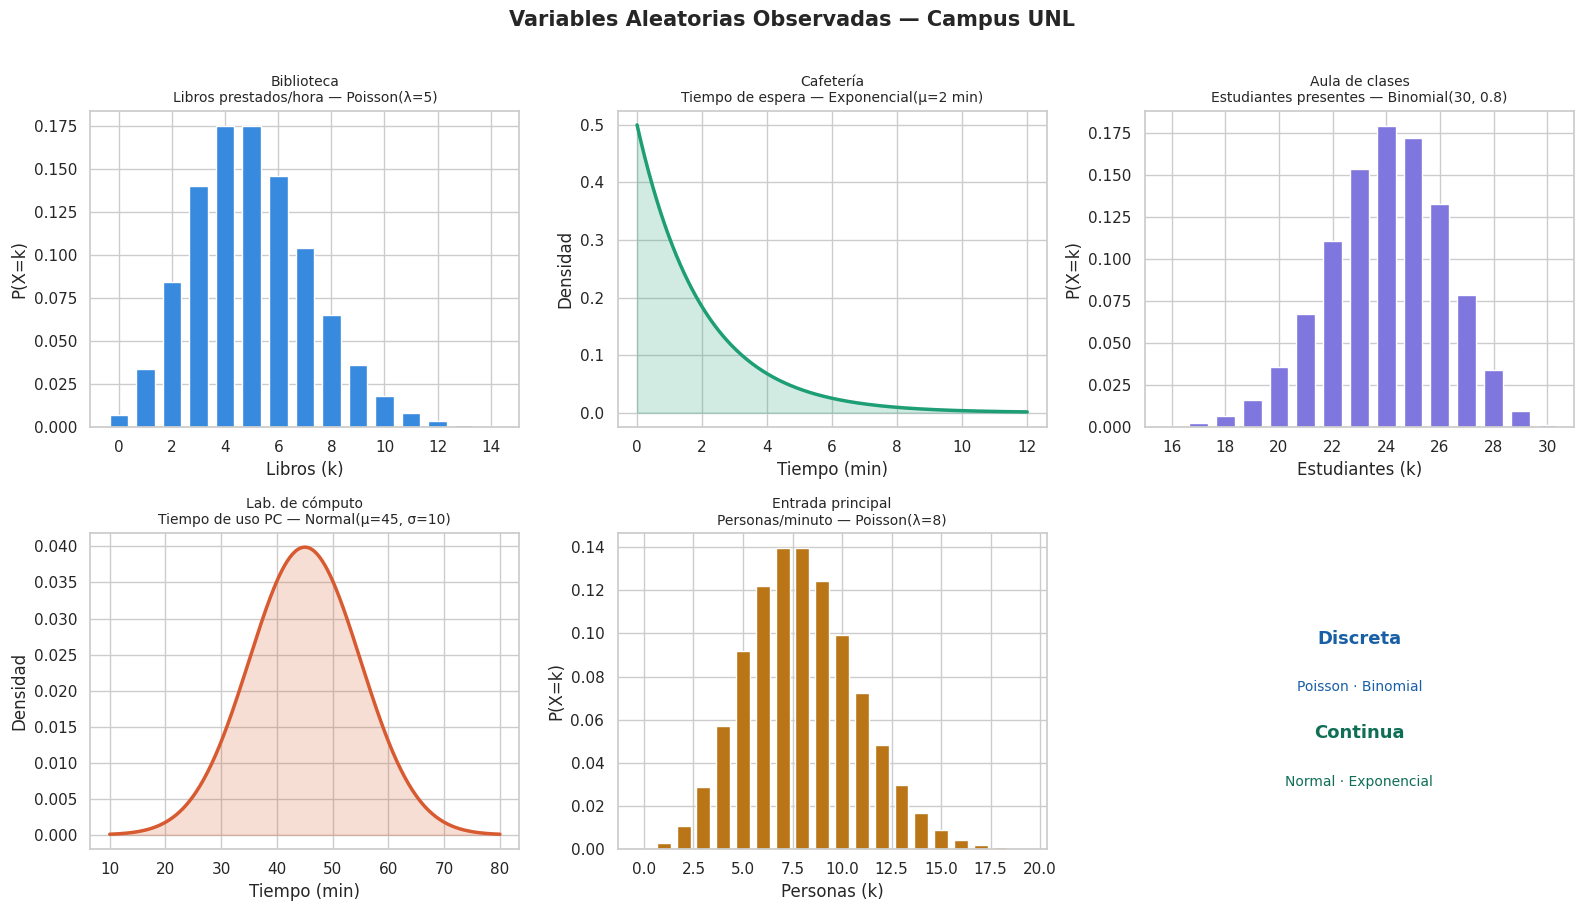

In [11]:
# ============================================================
# Gráfica de las 5 variables del campus con sus distribuciones
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

# 1. Biblioteca — Poisson (λ=5 préstamos/hora)
lam = 5
k   = np.arange(0, 15)
pmf_pois = stats.poisson.pmf(k, lam)
axes[0].bar(k, pmf_pois, color='#378ADD', edgecolor='white', width=0.7)
axes[0].set_title("Biblioteca\nLibros prestados/hora — Poisson(λ=5)", fontsize=10)
axes[0].set_xlabel("Libros (k)"); axes[0].set_ylabel("P(X=k)")

# 2. Cafetería — Exponencial (λ=0.5, media=2 min)
t    = np.linspace(0, 12, 300)
pdf_exp = stats.expon.pdf(t, scale=2)
axes[1].plot(t, pdf_exp, color='#1D9E75', linewidth=2.5)
axes[1].fill_between(t, pdf_exp, alpha=0.2, color='#1D9E75')
axes[1].set_title("Cafetería\nTiempo de espera — Exponencial(μ=2 min)", fontsize=10)
axes[1].set_xlabel("Tiempo (min)"); axes[1].set_ylabel("Densidad")

# 3. Aula — Binomial (n=30, p=0.8)
n_est, p_asist = 30, 0.80
k_bin = np.arange(0, n_est + 1)
pmf_bin = stats.binom.pmf(k_bin, n_est, p_asist)
axes[2].bar(k_bin, pmf_bin, color='#7F77DD', edgecolor='white', width=0.7)
axes[2].set_title("Aula de clases\nEstudiantes presentes — Binomial(30, 0.8)", fontsize=10)
axes[2].set_xlabel("Estudiantes (k)"); axes[2].set_ylabel("P(X=k)")
axes[2].set_xlim(15, 31)

# 4. Lab. cómputo — Normal (μ=45, σ=10 min)
x_lab = np.linspace(10, 80, 300)
pdf_lab = stats.norm.pdf(x_lab, 45, 10)
axes[3].plot(x_lab, pdf_lab, color='#D85A30', linewidth=2.5)
axes[3].fill_between(x_lab, pdf_lab, alpha=0.2, color='#D85A30')
axes[3].set_title("Lab. de cómputo\nTiempo de uso PC — Normal(μ=45, σ=10)", fontsize=10)
axes[3].set_xlabel("Tiempo (min)"); axes[3].set_ylabel("Densidad")

# 5. Entrada — Poisson (λ=8 personas/min)
lam2  = 8
k2    = np.arange(0, 20)
pmf_p2 = stats.poisson.pmf(k2, lam2)
axes[4].bar(k2, pmf_p2, color='#BA7517', edgecolor='white', width=0.7)
axes[4].set_title("Entrada principal\nPersonas/minuto — Poisson(λ=8)", fontsize=10)
axes[4].set_xlabel("Personas (k)"); axes[4].set_ylabel("P(X=k)")

# Ocultar el 6to panel vacío
axes[5].axis('off')

# Leyenda de tipos en el panel vacío
axes[5].text(0.5, 0.65, "Discreta", ha='center', fontsize=13,
             color='#185FA5', fontweight='bold', transform=axes[5].transAxes)
axes[5].text(0.5, 0.50, "Poisson · Binomial",
             ha='center', fontsize=10, color='#185FA5', transform=axes[5].transAxes)
axes[5].text(0.5, 0.35, "Continua", ha='center', fontsize=13,
             color='#0F6E56', fontweight='bold', transform=axes[5].transAxes)
axes[5].text(0.5, 0.20, "Normal · Exponencial",
             ha='center', fontsize=10, color='#0F6E56', transform=axes[5].transAxes)

plt.suptitle("Variables Aleatorias Observadas — Campus UNL",
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# **Autónomo - Diyer Torres**

══════════════════════════════════════════════════
  DISTRIBUCIÓN BINOMIAL B(n=15, p=0.5)
══════════════════════════════════════════════════
  Media     μ = 7.50
  Varianza  σ² = 3.75
  Desv. std σ = 1.94
══════════════════════════════════════════════════


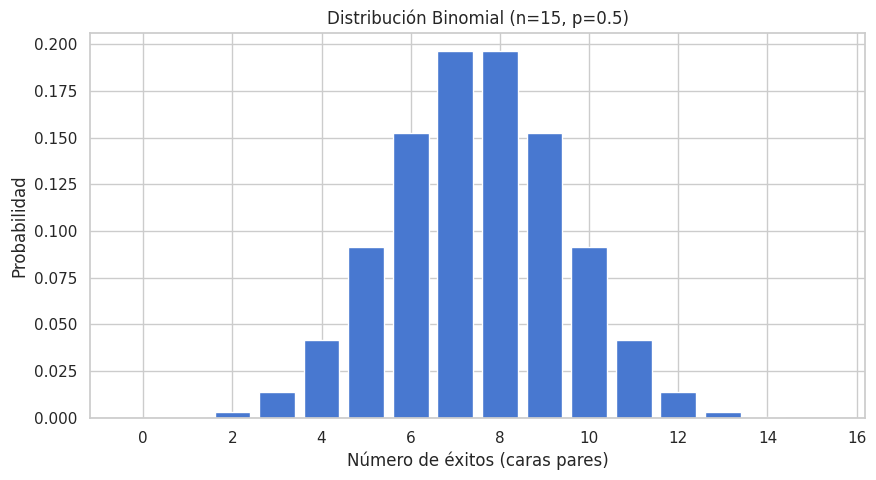

In [12]:
# ============================================================
# TRABAJO AUTÓNOMO: Distribución Binomial (MODIFICADA)
# Contexto: Lanzamiento de un dado (éxito = obtener número par)
# n = 15 lanzamientos, p = 0.5
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Parámetros
n = 15      # número de lanzamientos
p = 0.5     # probabilidad de obtener número par (2,4,6)

# Crear distribución Binomial
dist_binom = stats.binom(n=n, p=p)

# Espacio muestral
k = np.arange(0, n + 1)

# PMF y CDF
pmf_b = dist_binom.pmf(k)
cdf_b = dist_binom.cdf(k)

# Propiedades
media    = dist_binom.mean()
varianza = dist_binom.var()
desv_std = dist_binom.std()

print("═"*50)
print("  DISTRIBUCIÓN BINOMIAL B(n=15, p=0.5)")
print("═"*50)
print(f"  Media     μ = {media:.2f}")
print(f"  Varianza  σ² = {varianza:.2f}")
print(f"  Desv. std σ = {desv_std:.2f}")
print("═"*50)

# Gráfica
plt.figure()
plt.bar(k, pmf_b)
plt.title("Distribución Binomial (n=15, p=0.5)")
plt.xlabel("Número de éxitos (caras pares)")
plt.ylabel("Probabilidad")
plt.show()

In [13]:
# ============================================================
# Probabilidades específicas — análisis del experimento
# ============================================================

# P(X = 8): exactamente 8 veces sale número par
p_exacto = dist_binom.pmf(8)
print(f"P(X = 8)        = {p_exacto:.4f}  →  {p_exacto*100:.2f}%")

# P(X >= 10): al menos 10 resultados pares
p_geq10 = 1 - dist_binom.cdf(9)
print(f"P(X ≥ 10)       = {p_geq10:.4f}  →  {p_geq10*100:.2f}%")

# P(X <= 5): 5 o menos resultados pares
p_leq5 = dist_binom.cdf(5)
print(f"P(X ≤ 5)        = {p_leq5:.4f}  →  {p_leq5*100:.2f}%")

# P(6 <= X <= 9): rango cercano a la media
p_rango = dist_binom.cdf(9) - dist_binom.cdf(5)
print(f"P(6 ≤ X ≤ 9)    = {p_rango:.4f}  →  {p_rango*100:.2f}%")

# Conexión con Bernoulli (n=1)
print(f"\n--- Caso especial: Bernoulli = Binomial(n=1, p=0.5) ---")
bern = stats.binom(n=1, p=0.5)
print(f"P(X=1) éxito  = {bern.pmf(1):.4f}")
print(f"P(X=0) fracaso= {bern.pmf(0):.4f}")

P(X = 8)        = 0.1964  →  19.64%
P(X ≥ 10)       = 0.1509  →  15.09%
P(X ≤ 5)        = 0.1509  →  15.09%
P(6 ≤ X ≤ 9)    = 0.6982  →  69.82%

--- Caso especial: Bernoulli = Binomial(n=1, p=0.5) ---
P(X=1) éxito  = 0.5000
P(X=0) fracaso= 0.5000


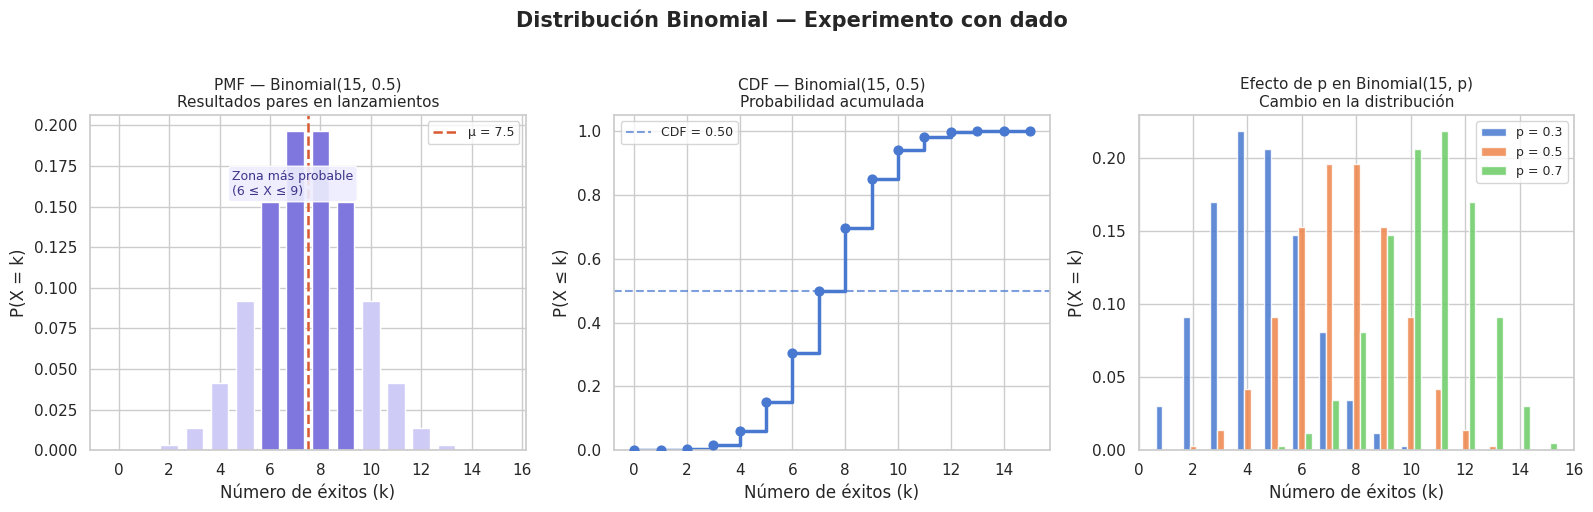

In [14]:
# ============================================================
# Gráfica completa: PMF + CDF + comparación con distintos p
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: PMF con rango resaltado (valores cercanos a la media)
colores_b = [
    '#7F77DD' if 6 <= ki <= 9
    else '#CECBF6'
    for ki in k
]

axes[0].bar(k, pmf_b, color=colores_b, edgecolor='white', width=0.7)
axes[0].axvline(media, color='#D85A30', linestyle='--',
                linewidth=1.8, label=f'μ = {media:.1f}')

axes[0].set_title("PMF — Binomial(15, 0.5)\nResultados pares en lanzamientos", fontsize=11)
axes[0].set_xlabel("Número de éxitos (k)")
axes[0].set_ylabel("P(X = k)")
axes[0].legend(fontsize=9)

axes[0].text(4.5, max(pmf_b)*0.8,
            'Zona más probable\n(6 ≤ X ≤ 9)',
            fontsize=9, color='#3C3489',
            bbox=dict(boxstyle='round,pad=0.3',
                      facecolor='#EEEDFE', alpha=0.9))

# Panel 2: CDF acumulada
axes[1].step(k, cdf_b, where='post', linewidth=2.5)
axes[1].scatter(k, cdf_b, zorder=5, s=40)

axes[1].axhline(0.5, linestyle='--',
                linewidth=1.5, alpha=0.7, label='CDF = 0.50')

axes[1].set_title("CDF — Binomial(15, 0.5)\nProbabilidad acumulada", fontsize=11)
axes[1].set_xlabel("Número de éxitos (k)")
axes[1].set_ylabel("P(X ≤ k)")
axes[1].set_ylim(0, 1.05)
axes[1].legend(fontsize=9)

# Panel 3: efecto de p
probs = [0.3, 0.5, 0.7]
ancho = 0.25

for i, pi in enumerate(probs):
    pmf_i = stats.binom.pmf(k, n, pi)
    axes[2].bar(k + (i - 1) * ancho, pmf_i,
               width=ancho,
               alpha=0.85, label=f'p = {pi}',
               edgecolor='white')

axes[2].set_title("Efecto de p en Binomial(15, p)\nCambio en la distribución", fontsize=11)
axes[2].set_xlabel("Número de éxitos (k)")
axes[2].set_ylabel("P(X = k)")
axes[2].set_xlim(0, 16)
axes[2].legend(fontsize=9)

plt.suptitle("Distribución Binomial — Experimento con dado",
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

## **DISTRIBUCIÓN BINOMIAL — Interpretación de resultados**

**Modelo:**

X ~ B(n = 15, p = 0.5)

Contexto:
La variable aleatoria X representa el número de veces que se obtiene un número par al lanzar un dado 15 veces. Se considera éxito obtener un número par (2, 4 o 6), con probabilidad p = 0.5.

**Condiciones que justifican la Binomial:**
1. Número fijo de ensayos: n = 15 lanzamientos del dado.
2. Cada ensayo es independiente (un lanzamiento no afecta a otro).
3. Solo existen dos resultados posibles: par (éxito) o impar (fracaso).
4. La probabilidad de éxito se mantiene constante en cada lanzamiento (p = 0.5).

**Resultados clave:**
- Se espera en promedio μ = 7.5 éxitos.
- Los valores cercanos a 7 y 8 son los más probables, mostrando una distribución aproximadamente simétrica.
- La mayor concentración de probabilidad se encuentra entre 6 y 9 éxitos.
- Resultados muy bajos o muy altos tienen menor probabilidad de ocurrir.

**Relación con Bernoulli:**
La distribución Binomial se construye a partir de múltiples ensayos Bernoulli independientes.
Cada lanzamiento del dado es un experimento Bernoulli:
- Éxito → número par
- Fracaso → número impar

Cuando n = 1, la distribución Binomial se reduce a una distribución Bernoulli.

## **Preguntas de Control**

---

### 1. ¿Cuál es la diferencia fundamental entre una variable aleatoria discreta y una continua?

La diferencia principal es que:

- **Variable discreta:** toma valores específicos y contables (por ejemplo: 0, 1, 2, 3, ...).  
- **Variable continua:** puede tomar infinitos valores dentro de un intervalo (por ejemplo: cualquier número real entre 0 y 1).

Además:
- Las variables discretas usan una **función de probabilidad (PMF)**.  
- Las variables continuas usan una **función de densidad (PDF)**.

---

### 2. ¿Por qué en una variable continua \(P(X = x) = 0\)?

En una variable continua hay infinitos valores posibles, por lo que la probabilidad no se asigna a un valor exacto, sino a intervalos.

\[
P(a < X < b)
\]

Matemáticamente, la probabilidad se calcula mediante una **integral**, y el área en un solo punto es cero. Por eso:

\[
P(X = x) = 0
\]

---

### 3. Relación entre PMF/PDF y la CDF

- **Variable discreta:**
\[
F(x) = P(X \leq x) = \sum P(X = k)
\]

- **Variable continua:**
\[
F(x) = \int_{-\infty}^{x} f(t)\,dt
\]

- **Relación inversa (continua):**
\[
f(x) = \frac{d}{dx}F(x)
\]

---

### 4. Variable: número de estudiantes que llegan tarde

Esta variable es **discreta**, porque representa un conteo.

Solo puede tomar valores enteros:
\[
0, 1, 2, 3, ...
\]

No puede tomar valores decimales.

---

### 5. Calcular \(P(X = 5)\) para \(f(x) = 2x\) en \([0,1]\)

\[
P(X = 5) = 0
\]

Porque:
- Es una variable continua  
- La probabilidad en un punto es cero  
- Además, \(x = 5\) está fuera del intervalo \([0,1]\)

---

### 6. CDF para valores \{1, 2, 3\}

La función de distribución acumulada es:

- \(F(x) = 0\) si \(x < 1\)  
- \(F(x) = 0.3\) si \(1 \leq x < 2\)  
- \(F(x) = 0.8\) si \(2 \leq x < 3\)  
- \(F(x) = 1\) si \(x \geq 3\)

Es una función escalonada.

---

### 7. Variable continua en Computación

**Ejemplo:** tiempo de ejecución de un programa.

Es continua porque:
- Puede tomar valores reales (ej: 0.5, 1.23 segundos)  
- No está limitada a números enteros  
- Se mide dentro de un intervalo continuo

---